### Ejercicio 3 — Dataset propio: Bank Marketing

**Objetivo.** Predecir si un cliente contratará un depósito a plazo tras una campaña telefónica de un banco portugués, comparando cuatro modelos de la sesión (Regresión Logística, Árbol de Decisión, SVM y KNN) y un quinto modelo adicional (Random Forest). Se documentan métricas, matrices de confusión, curvas ROC, una matriz de selección y la justificación del mejor modelo.

**Dataset.** *Bank Marketing* (Moro, Cortez y Rita, UCI Machine Learning Repository), en la versión de Kaggle (`bank.csv`). Cumple el enunciado: 11 162 registros (mínimo 500) y 16 variables (mínimo 5), de las cuales 7 son numéricas y 9 categóricas. La variable objetivo es `deposit` (`yes` / `no`).

**Decisión sobre `duration`.** La duración de la llamada solo se conoce cuando la llamada ya terminó, por lo que no puede usarse para decidir a quién llamar. Aun así, se **incluye** en el análisis principal por ser la variable más informativa del dataset. Esto implica que las métricas describen el resultado de una llamada ya realizada y no la capacidad de seleccionar clientes antes de llamar. Esta limitación se retoma en las conclusiones.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42
df = pd.read_csv('bank.csv')

print('Dimensiones:', df.shape)
print('Nulos:', int(df.isna().sum().sum()), '| Duplicados:', int(df.duplicated().sum()))
print('\nDistribución de deposit:')
print(df['deposit'].value_counts().to_frame('n').assign(pct=lambda t: (t['n'] / len(df) * 100).round(1)))

cat_raw = df.select_dtypes(exclude='number').columns.drop('deposit')
print('\nValores "unknown" por variable:')
print({c: int((df[c] == 'unknown').sum()) for c in cat_raw if (df[c] == 'unknown').any()})
print('\npdays == -1 (sin contacto previo):', int((df['pdays'] == -1).sum()))
df.head()

Dimensiones: (11162, 17)
Nulos: 0 | Duplicados: 0

Distribución de deposit:
            n   pct
deposit            
no       5873  52.6
yes      5289  47.4

Valores "unknown" por variable:
{'job': 70, 'education': 497, 'contact': 2346, 'poutcome': 8326}

pdays == -1 (sin contacto previo): 8324


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


#### Carga y exploración

Antes de modelar se revisa la calidad del dato. No hay nulos ni duplicados, y las clases están casi balanceadas (52.6 % `no` y 47.4 % `yes`), por lo que no hace falta `class_weight` ni SMOTE y las métricas estándar (accuracy, F1, AUC) son interpretables. Los valores ausentes no aparecen como nulos sino como la categoría `unknown` (sobre todo en `poutcome` y `contact`), y `pdays = -1` indica que el cliente no había sido contactado antes.

#### Preprocesamiento

- **`unknown`** se conserva como una categoría más dentro del one-hot, porque su presencia puede ser informativa (por ejemplo, `poutcome = unknown` equivale a "sin campaña previa").
- **`pdays`**: el valor `-1` distorsiona las distancias de KNN y SVM. Se crea el indicador binario `contactado_antes` y `pdays` se reemplaza por 0 cuando no hubo contacto previo. Es una transformación fila a fila, sin uso de otras filas, por lo que no genera fuga de información.
- **Numéricas** estandarizadas y **categóricas** con one-hot, dentro de un `Pipeline`, de modo que el ajuste del preprocesador ocurre solo con los datos de entrenamiento de cada fold.
- **Partición** 80 / 20 estratificada (`random_state=42`) y validación cruzada estratificada de 5 folds sobre el train. El test se usa una sola vez, al final.

In [2]:
# Feature engineering determinista (fila a fila: no hay fuga de información)
df_m = df.copy()
df_m['contactado_antes'] = (df_m['pdays'] != -1).astype(int)
df_m['pdays'] = df_m['pdays'].where(df_m['pdays'] != -1, 0)

y = (df_m['deposit'] == 'yes').astype(int)      # 1 = contrata el depósito (clase positiva)
X = df_m.drop(columns='deposit')

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print('Numéricas :', num_cols)
print('Categóricas:', cat_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def nuevo_preprocesador():
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

n_cols = nuevo_preprocesador().fit(X_train).transform(X_train.iloc[:5]).shape[1]
print(f'\nTrain: {X_train.shape} | Test: {X_test.shape} | Columnas tras one-hot: {n_cols}')
print(f'Positivos en train: {y_train.mean():.3f} | en test: {y_test.mean():.3f}')

Numéricas : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'contactado_antes']
Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Train: (8929, 17) | Test: (2233, 17) | Columnas tras one-hot: 52
Positivos en train: 0.474 | en test: 0.474


#### Modelos y búsqueda de hiperparámetros

Se ajustan los cuatro modelos de la sesión y Random Forest como quinto modelo. Cada uno se optimiza con `GridSearchCV` (5 folds, `scoring='f1'`, clase positiva = `yes`). La malla de cada modelo es la siguiente:

| Modelo | Hiperparámetros explorados |
|---|---|
| Regresión Logística | `C`: 0.01, 0.1, 1, 10 |
| Árbol de Decisión | `max_depth`: 3, 5, 7, 10, None; `min_samples_leaf`: 1, 5, 10 |
| SVM (RBF) | `C`: 0.1, 1, 10; `gamma`: scale, 0.01 |
| KNN | `n_neighbors`: 5, 9, 15, 21, 31; `weights`: uniform, distance |
| Random Forest (200 árboles) | `max_depth`: 10, 20, None; `min_samples_leaf`: 1, 3, 5 |

In [3]:
configs = {
    'Regresión Logística': (LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                            {'clf__C': [0.01, 0.1, 1, 10]}),
    'Árbol de Decisión':   (DecisionTreeClassifier(random_state=RANDOM_STATE),
                            {'clf__max_depth': [3, 5, 7, 10, None], 'clf__min_samples_leaf': [1, 5, 10]}),
    'SVM (RBF)':           (SVC(kernel='rbf', random_state=RANDOM_STATE),
                            {'clf__C': [0.1, 1, 10], 'clf__gamma': ['scale', 0.01]}),
    'KNN':                 (KNeighborsClassifier(),
                            {'clf__n_neighbors': [5, 9, 15, 21, 31], 'clf__weights': ['uniform', 'distance']}),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
                            {'clf__max_depth': [10, 20, None], 'clf__min_samples_leaf': [1, 3, 5]}),
}

mejores = {}
for nombre, (clf, grid) in configs.items():
    pipe = Pipeline([('prep', nuevo_preprocesador()), ('clf', clf)])
    gs = GridSearchCV(pipe, grid, cv=skf, scoring='f1', n_jobs=-1)
    t0 = time.time()
    gs.fit(X_train, y_train)
    mejores[nombre] = gs
    print(f'{nombre:20s} F1 CV = {gs.best_score_:.4f}  {gs.best_params_}  ({time.time() - t0:.0f} s)')

Regresión Logística  F1 CV = 0.8106  {'clf__C': 1}  (1 s)


Árbol de Decisión    F1 CV = 0.8145  {'clf__max_depth': 10, 'clf__min_samples_leaf': 10}  (4 s)


SVM (RBF)            F1 CV = 0.8460  {'clf__C': 1, 'clf__gamma': 'scale'}  (53 s)


KNN                  F1 CV = 0.7929  {'clf__n_neighbors': 9, 'clf__weights': 'distance'}  (5 s)


Random Forest        F1 CV = 0.8485  {'clf__max_depth': 20, 'clf__min_samples_leaf': 3}  (59 s)


#### Evaluación en el conjunto de test

Con los mejores hiperparámetros de cada modelo se calculan las métricas sobre el test, que ningún modelo había visto. Además del rendimiento se registra la **brecha train−CV** (F1 en train menos F1 en validación cruzada, como indicador de sobreajuste) y el **tiempo de entrenamiento** de un ajuste completo sobre el train. La clase positiva es `yes`, por lo que en la matriz de confusión un falso positivo es un cliente contactado que no contrata y un falso negativo es un cliente que habría contratado y el modelo descarta.

In [4]:
def puntuacion(modelo, X_):
    # Probabilidad de la clase positiva; para SVM (sin probability) se usa la función de decisión
    if hasattr(modelo, 'predict_proba'):
        return modelo.predict_proba(X_)[:, 1]
    return modelo.decision_function(X_)

pred, score, filas = {}, {}, []
for nombre, gs in mejores.items():
    modelo = gs.best_estimator_
    t0 = time.time(); clone(modelo).fit(X_train, y_train); t_fit = time.time() - t0
    yp = modelo.predict(X_test)
    pred[nombre], score[nombre] = yp, puntuacion(modelo, X_test)
    f1_tr = f1_score(y_train, modelo.predict(X_train))
    filas.append({
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp),
        'Recall':    recall_score(y_test, yp),
        'F1':        f1_score(y_test, yp),
        'AUC':       roc_auc_score(y_test, score[nombre]),
        'F1 CV':     gs.best_score_,
        'F1 train':  f1_tr,
        'Brecha train−CV': f1_tr - gs.best_score_,
        'Tiempo fit (s)':  t_fit,
    })

resultados = pd.DataFrame(filas).set_index('Modelo')
resultados.round(4)

,Accuracy,Precision,Recall,F1,AUC,F1 CV,F1 train,Brecha train−CV,Tiempo fit (s)
Modelo,,,,,,,,,
Regresión Logística,0.8262,0.8284,0.7987,0.8133,0.9071,0.8106,0.8136,0.0030,0.0557
Árbol de Decisión,0.8204,0.7839,0.8573,0.8190,0.8952,0.8145,0.8475,0.0330,0.0596
SVM (RBF),0.8562,0.8258,0.8828,0.8534,0.9193,0.8460,0.8727,0.0266,1.8173
KNN,0.8231,0.8228,0.7987,0.8106,0.8935,0.7929,1.0000,0.2071,0.0193
Random Forest,0.8540,0.8194,0.8875,0.8521,0.9197,0.8485,0.9214,0.0730,1.6205


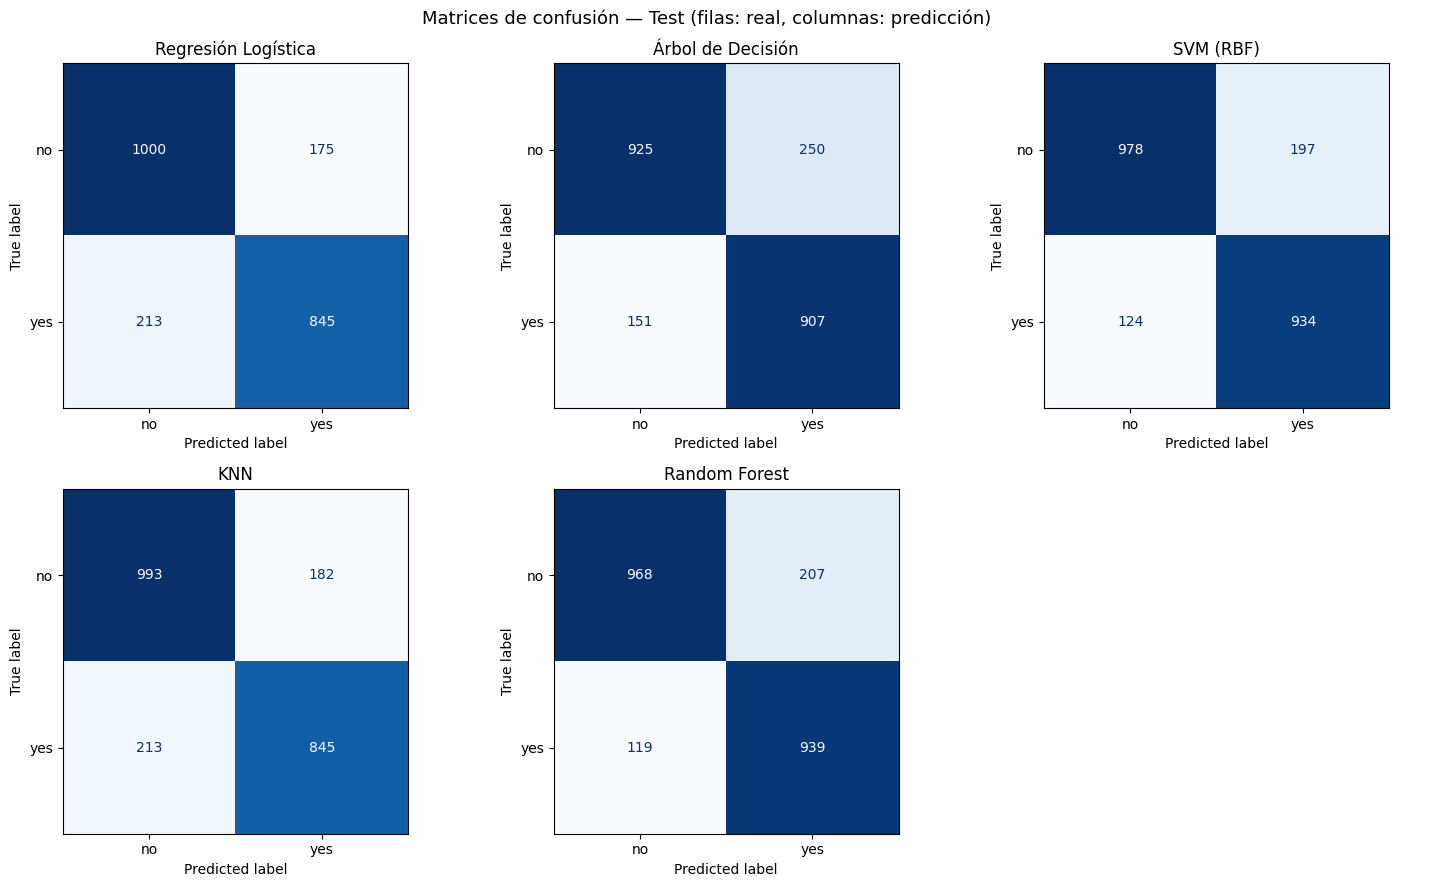

Errores en test (clase positiva = yes):
  Regresión Logística  FP (llamada sin contrato) =  175 | FN (cliente perdido) =  213
  Árbol de Decisión    FP (llamada sin contrato) =  250 | FN (cliente perdido) =  151
  SVM (RBF)            FP (llamada sin contrato) =  197 | FN (cliente perdido) =  124
  KNN                  FP (llamada sin contrato) =  182 | FN (cliente perdido) =  213
  Random Forest        FP (llamada sin contrato) =  207 | FN (cliente perdido) =  119


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (nombre, yp) in zip(axes.flatten(), pred.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, yp, display_labels=['no', 'yes'], cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(nombre)
axes.flatten()[-1].axis('off')
plt.suptitle('Matrices de confusión — Test (filas: real, columnas: predicción)', fontsize=13)
plt.tight_layout()
plt.show()

print('Errores en test (clase positiva = yes):')
for nombre, yp in pred.items():
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    print(f'  {nombre:20s} FP (llamada sin contrato) = {fp:4d} | FN (cliente perdido) = {fn:4d}')

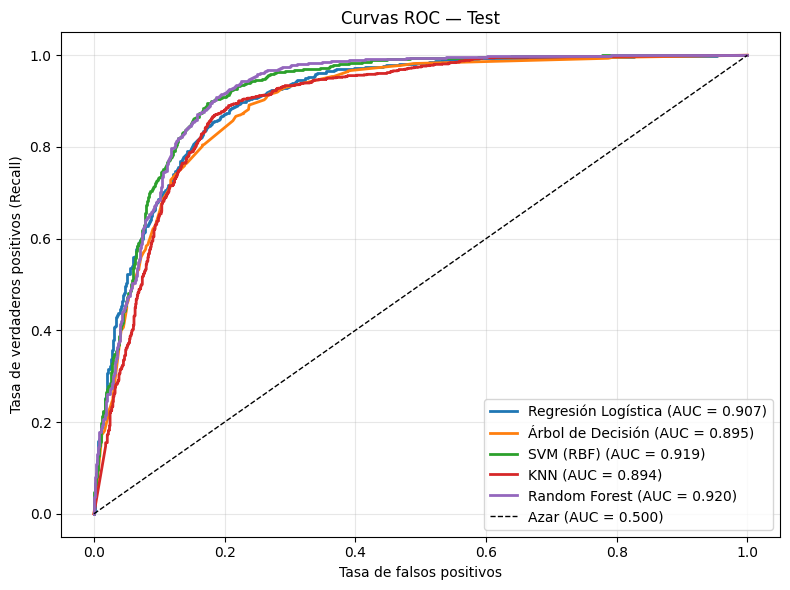

In [6]:
plt.figure(figsize=(8, 6))
for nombre, s in score.items():
    fpr, tpr, _ = roc_curve(y_test, s)
    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {roc_auc_score(y_test, s):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Azar (AUC = 0.500)')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos (Recall)')
plt.title('Curvas ROC — Test')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Resultados en test y lectura de las métricas

Mejores hiperparámetros encontrados: Regresión Logística `C=1`; Árbol `max_depth=10`, `min_samples_leaf=10`; SVM `C=1`, `gamma='scale'`; KNN `n_neighbors=9`, `weights='distance'`; Random Forest `max_depth=20`, `min_samples_leaf=3`.

| Modelo | F1 | AUC | Accuracy | Precision | Recall | FP | FN | Tiempo fit (s) |
|---|---|---|---|---|---|---|---|---|
| Regresión Logística | 0.8133 | 0.9071 | 0.8262 | 0.8284 | 0.7987 | 175 | 213 | 0.056 |
| Árbol de Decisión | 0.8190 | 0.8952 | 0.8204 | 0.7839 | 0.8573 | 250 | 151 | 0.060 |
| SVM (RBF) | 0.8534 | 0.9193 | 0.8562 | 0.8258 | 0.8828 | 197 | 124 | 1.817 |
| KNN | 0.8106 | 0.8935 | 0.8231 | 0.8228 | 0.7987 | 182 | 213 | 0.019 |
| Random Forest | 0.8521 | 0.9197 | 0.8540 | 0.8194 | 0.8875 | 207 | 119 | 1.620 |

1. **SVM y Random Forest lideran** en todas las métricas de rendimiento, con diferencias mínimas entre ellos (F1 0.8534 vs 0.8521; AUC 0.9193 vs 0.9197).
2. **Random Forest es el que deja escapar menos clientes** (119 falsos negativos, frente a 124 del SVM y 213 de la Regresión Logística y KNN), a cambio de más llamadas sin contrato (207 falsos positivos, frente a 175 de la Regresión Logística).
3. **El Árbol de Decisión** tiene buen recall (0.857) pero la menor precisión (0.784): contacta a muchos clientes que no contratan.
4. **No hay sobreajuste hacia el test.** El F1 en test es entre 0.003 y 0.018 puntos mayor que el F1 en validación cruzada en los cinco modelos, así que la estimación de la validación cruzada no fue optimista.
5. **La brecha train−CV de KNN (0.207) es un artefacto**, no evidencia de sobreajuste real. Con `weights='distance'` cada punto de entrenamiento es su propio vecino más cercano a distancia cero, por lo que el F1 en train es exactamente 1.0. Aun así, KNN queda último en F1 y AUC por sus resultados en test. La brecha de Random Forest (0.073) sí es moderada: se ajusta más al train, pero obtiene el mayor F1 en validación cruzada (0.8485).

#### ¿Las diferencias son reales? (bootstrap sobre el test)

Con 2233 registros de test, cada AUC tiene un margen de error. Se repite 1000 veces la evaluación con muestras del test extraídas al azar con reemplazo (los mismos registros para todos los modelos) y se toma el rango que contiene el 95 % central. Si dos intervalos se solapan, no se puede afirmar que un modelo sea mejor que otro. Este bootstrap solo captura la variabilidad del test, no la del entrenamiento.

In [7]:
rng = np.random.default_rng(RANDOM_STATE)
yt = y_test.to_numpy()
idx_boot = [rng.integers(0, len(yt), len(yt)) for _ in range(1000)]

aucs = {n: np.array([roc_auc_score(yt[i], s[i]) for i in idx_boot]) for n, s in score.items()}
ic = pd.DataFrame({
    n: {'AUC test': roc_auc_score(yt, score[n]),
        'IC95% inf': np.percentile(a, 2.5),
        'IC95% sup': np.percentile(a, 97.5)}
    for n, a in aucs.items()}).T.round(4)
display(ic)

mejor_auc = resultados['AUC'].idxmax()
print(f'Diferencia de AUC frente a {mejor_auc} (bootstrap pareado, IC 95 %):')
for n in aucs:
    if n == mejor_auc:
        continue
    d = aucs[mejor_auc] - aucs[n]
    lo, hi = np.percentile(d, [2.5, 97.5])
    print(f'  {mejor_auc} − {n:20s}: media = {d.mean():+.4f}   IC95% = [{lo:+.4f}, {hi:+.4f}]')

,AUC test,IC95% inf,IC95% sup
Regresión Logística,0.9071,0.8960,0.9189
Árbol de Decisión,0.8952,0.8812,0.9086
SVM (RBF),0.9193,0.9083,0.9300
KNN,0.8935,0.8802,0.9065
Random Forest,0.9197,0.9080,0.9309


Diferencia de AUC frente a Random Forest (bootstrap pareado, IC 95 %):
  Random Forest − Regresión Logística : media = +0.0124   IC95% = [+0.0051, +0.0192]
  Random Forest − Árbol de Decisión   : media = +0.0245   IC95% = [+0.0157, +0.0331]
  Random Forest − SVM (RBF)           : media = +0.0005   IC95% = [-0.0050, +0.0058]
  Random Forest − KNN                 : media = +0.0262   IC95% = [+0.0172, +0.0350]


#### Lectura del bootstrap

- **Random Forest y SVM están empatados en AUC**: la diferencia media es +0.0005 y su intervalo (−0.0050 a +0.0058) incluye el cero.
- **Random Forest supera a los otros tres modelos** con intervalos que no incluyen el cero: +0.0124 frente a la Regresión Logística (IC 95 %: +0.0051 a +0.0192), +0.0245 frente al Árbol y +0.0262 frente a KNN.
- No se comparó directamente el SVM con los otros tres modelos, por lo que esa afirmación se limita a Random Forest. Los intervalos son pequeños en términos absolutos: la ventaja sobre la Regresión Logística es de 1.2 puntos de AUC.

#### Variables más influyentes

Se revisa qué variables pesan más en el Random Forest (importancia por reducción de impureza) y en la Regresión Logística (coeficientes sobre variables estandarizadas, por lo que son comparables entre sí). Esto permite documentar el peso de `duration` y evaluar la interpretabilidad de cada modelo.

In [8]:
rf = mejores['Random Forest'].best_estimator_
nombres_rf = rf.named_steps['prep'].get_feature_names_out()
imp_rf = pd.Series(rf.named_steps['clf'].feature_importances_, index=nombres_rf).sort_values(ascending=False)
print('Random Forest — top 8 importancias:')
print(imp_rf.head(8).round(4).to_string())

lr = mejores['Regresión Logística'].best_estimator_
coef = pd.Series(lr.named_steps['clf'].coef_[0],
                 index=lr.named_steps['prep'].get_feature_names_out())
print('\nRegresión Logística — top 8 por |coeficiente|:')
print(coef.reindex(coef.abs().sort_values(ascending=False).index).head(8).round(3).to_string())

Random Forest — top 8 importancias:
num__duration            0.3945
num__balance             0.0601
num__age                 0.0593
num__day                 0.0499
cat__poutcome_success    0.0439
num__pdays               0.0329
cat__contact_unknown     0.0281
num__campaign            0.0242

Regresión Logística — top 8 por |coeficiente|:
num__duration            1.858
cat__month_mar           1.773
cat__poutcome_success    1.447
cat__month_dec           1.218
cat__month_jan          -1.139
cat__month_jul          -1.010
cat__month_nov          -0.970
cat__contact_unknown    -0.966


#### Lectura de las variables influyentes

- **`duration` domina ambos modelos.** En Random Forest su importancia es 0.3945, más de seis veces la de la siguiente variable (`balance`, 0.0601). En la Regresión Logística tiene el mayor coeficiente en valor absoluto (1.858) entre variables estandarizadas.
- Otras variables relevantes: haber tenido éxito en una campaña previa (`poutcome = success`, coeficiente +1.447) y el mes de contacto (marzo y diciembre con coeficientes positivos; enero, julio y noviembre con negativos), además de `contact = unknown` (−0.966).
- Estos coeficientes describen asociaciones en los datos, no causas.

#### Matriz de selección

Para elegir el modelo se combinan cinco criterios en una **matriz de selección ponderada**. Cada criterio se normaliza entre 0 (peor modelo) y 1 (mejor modelo) y se multiplica por su peso.

| Criterio | Cómo se mide | Peso (principal) |
|---|---|---|
| F1 en test | Equilibrio entre precisión y recall de la clase `yes` | 0.30 |
| AUC en test | Capacidad de ordenar clientes, independiente del umbral | 0.25 |
| Generalización | Menos brecha train−CV es mejor | 0.15 |
| Velocidad | Menos tiempo de entrenamiento es mejor | 0.10 |
| Interpretabilidad | Puntuación subjetiva de 1 a 5 | 0.20 |

Los pesos y la puntuación de interpretabilidad son **juicios del autor**, no resultados medidos. Por eso se repite el cálculo con otros dos conjuntos de pesos (solo desempeño y priorizando interpretabilidad) para comprobar si el ranking cambia.

In [9]:
interpretabilidad = pd.Series({'Regresión Logística': 5, 'Árbol de Decisión': 4, 'KNN': 3,
                               'Random Forest': 2, 'SVM (RBF)': 1})

crit = pd.DataFrame({
    'F1 test':           resultados['F1'],
    'AUC test':          resultados['AUC'],
    'Generalización':    -resultados['Brecha train−CV'],
    'Velocidad':         -resultados['Tiempo fit (s)'],
    'Interpretabilidad': interpretabilidad,
})
norm = (crit - crit.min()) / (crit.max() - crit.min())

escenarios = {
    'Principal':                   [0.30, 0.25, 0.15, 0.10, 0.20],
    'Solo desempeño':              [0.40, 0.35, 0.15, 0.05, 0.05],
    'Prioriza interpretabilidad':  [0.20, 0.15, 0.15, 0.10, 0.40],
}
totales = pd.DataFrame({esc: norm.mul(w, axis=1).sum(axis=1) for esc, w in escenarios.items()})

print('Criterios normalizados (0 = peor, 1 = mejor):')
display(norm.round(3))
print('Puntaje total por escenario de pesos:')
display(totales.round(3))
print('Ranking (1 = mejor):')
display(totales.rank(ascending=False).astype(int))

Criterios normalizados (0 = peor, 1 = mejor):


,F1 test,AUC test,Generalización,Velocidad,Interpretabilidad
KNN,0.000,0.000,0.000,1.000,0.50
Random Forest,0.970,1.000,0.657,0.109,0.25
Regresión Logística,0.064,0.520,1.000,0.980,1.00
SVM (RBF),1.000,0.984,0.884,0.000,0.00
Árbol de Decisión,0.196,0.064,0.853,0.978,0.75


Puntaje total por escenario de pesos:


,Principal,Solo desempeño,Prioriza interpretabilidad
KNN,0.200,0.075,0.300
Random Forest,0.701,0.855,0.554
Regresión Logística,0.597,0.456,0.739
SVM (RBF),0.679,0.877,0.480
Árbol de Decisión,0.451,0.315,0.575


Ranking (1 = mejor):


,Principal,Solo desempeño,Prioriza interpretabilidad
KNN,5,5,5
Random Forest,1,2,3
Regresión Logística,3,3,1
SVM (RBF),2,1,4
Árbol de Decisión,4,4,2


#### Conclusiones — Ejercicio 3: Bank Marketing

**Matriz de selección (puntaje total, 0 a 1).**

| Modelo | Principal | Solo desempeño | Prioriza interpretabilidad |
|---|---|---|---|
| Random Forest | **0.701** | 0.855 | 0.554 |
| SVM (RBF) | 0.679 | **0.877** | 0.480 |
| Regresión Logística | 0.597 | 0.456 | **0.739** |
| Árbol de Decisión | 0.451 | 0.315 | 0.575 |
| KNN | 0.200 | 0.075 | 0.300 |

**Modelo recomendado: Random Forest.**
- Está empatado con el SVM en rendimiento (AUC +0.0005, IC 95 %: −0.0050 a +0.0058; F1 0.8521 vs 0.8534) y supera a los otros tres en AUC con intervalos que excluyen el cero.
- Es el modelo con menos falsos negativos en test (119), es decir, el que menos clientes interesados deja sin contactar.
- Gana la matriz con los pesos principales (0.701 frente a 0.679 del SVM) y, a diferencia del SVM, permite ver la importancia de las variables y no requiere escalado.

**Cuánto depende la elección de los pesos.** La preferencia de Random Forest sobre el SVM **no se apoya en el rendimiento**, donde están empatados, sino en criterios secundarios. Con el escenario "solo desempeño" el primero es el SVM (0.877 frente a 0.855), y si se prioriza la interpretabilidad el primero es la Regresión Logística (0.739), con Random Forest en tercer lugar.

**Alternativa si se exige interpretabilidad:** Regresión Logística. Cuesta unos 0.039 puntos de F1 (0.8133 vs 0.8521) y 0.012 de AUC (una diferencia que el bootstrap indica como real), pero sus coeficientes son explicables y entrena en una fracción de segundo.

**Limitaciones.**
- **`duration` está incluida por decisión del análisis.** Su valor solo se conoce cuando la llamada termina, así que estas métricas describen el resultado de una llamada ya hecha y no la capacidad de decidir a quién llamar. En una comprobación previa con hiperparámetros por defecto, sin `duration` el AUC bajaba a 0.758 (Regresión Logística) y 0.780 (Random Forest), unos 0.14 puntos menos.
- **La matriz de selección incluye juicios subjetivos**: los pesos y la puntuación de interpretabilidad (1 a 5) los fija el autor. Además, la normalización min-max exagera diferencias pequeñas: el tiempo de ajuste de Random Forest (1.62 s) y SVM (1.82 s) es casi igual, pero se les asignan valores de velocidad de 0.109 y 0.000.
- El bootstrap solo captura la variabilidad del conjunto de test, no la del entrenamiento. Se usó una única partición 80/20 y mallas de hiperparámetros pequeñas.
- Se usó el umbral de decisión por defecto (0.5) y no se cuantificó el costo relativo de un falso positivo (llamada perdida) frente a un falso negativo (cliente perdido).

**Trabajo futuro:** repetir el análisis sin `duration` para medir la capacidad predictiva previa a la llamada, ajustar el umbral según el costo de cada error, probar Gradient Boosting y calibrar las probabilidades.